In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor

## Preparing the dataset
### Preparation:

- Fill missing values with zeros.
- Do train/validation/test split with 60%/20%/20% distribution.
- Use the train_test_split function and set the random_state parameter to 1.
- Use DictVectorizer(sparse=True) to turn the dataframes into matrices.

In [2]:
df = pd.read_csv("car_fuel_efficiency.csv")

In [3]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [5]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df = df.fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9704 non-null   float64
 2   horsepower           9704 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         9704 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9704 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [7]:
full_train, test = train_test_split(df, test_size=0.2, random_state=1)

In [8]:
train, val = train_test_split(full_train, test_size=0.25, random_state=1)

In [9]:
len(train) + len(val) + len(test)

9704

In [10]:
len(df)

9704

----

In [11]:
X_train = train.drop("fuel_efficiency_mpg", axis=1)
y_train = train["fuel_efficiency_mpg"]
###
X_val = val.drop("fuel_efficiency_mpg", axis=1)
y_val = val["fuel_efficiency_mpg"]
####
X_test = test.drop("fuel_efficiency_mpg", axis=1)
y_test = test["fuel_efficiency_mpg"]

In [12]:
X_train_dc = X_train.to_dict("records")

In [13]:
X_val_dc = X_val.to_dict("records")

In [14]:
X_test_dc = X_test.to_dict("records")

---

In [15]:
dv = DictVectorizer(sparse=True)

In [16]:
X_train_dv = dv.fit_transform(X_train_dc)

In [17]:
X_val_dv = dv.transform(X_val_dc)

# Question 1
## Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

### Train a model with max_depth=1.
### Which feature is used for splitting the data?

- 'vehicle_weight'
- 'model_year'
- 'origin'
- 'fuel_type'

In [18]:
model = DecisionTreeRegressor(max_depth=1)

In [19]:
model.fit(X_train_dv, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
features = dv.get_feature_names_out()

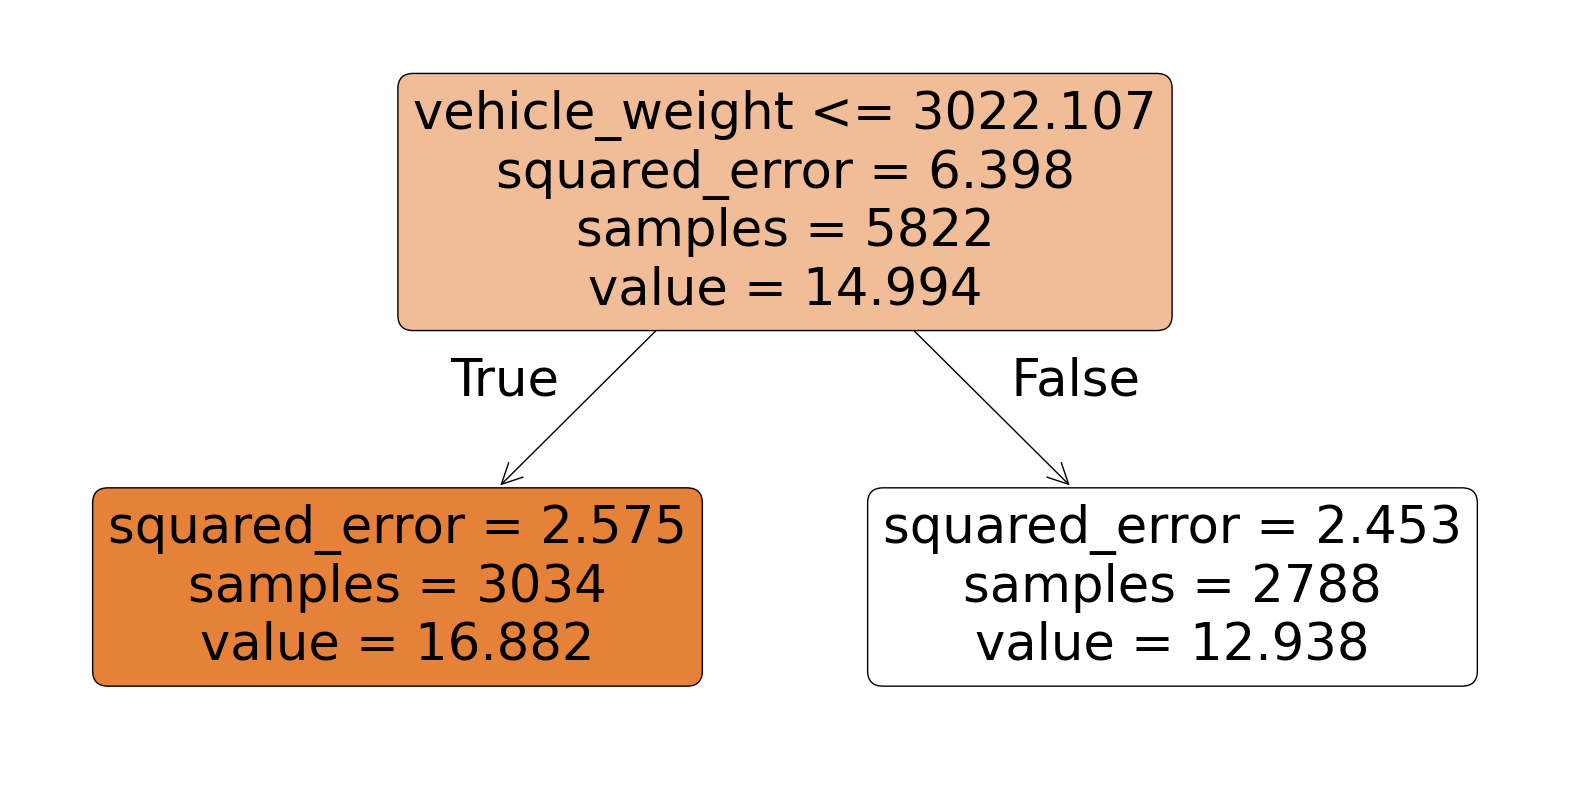

In [21]:
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=features, rounded=True)
plt.show()

----

## Question 2
### Train a random forest regressor with these parameters:

- n_estimators=10
- random_state=1
- n_jobs=-1 (optional - to make training faster)
### What's the RMSE of this model on the validation data?

- 0.045
- 0.45
- 4.5
- 45.0

In [22]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)

In [23]:
rf.fit(X_train_dv, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_val_hat = rf.predict(X_val_dv)

In [25]:
root_mean_squared_error(y_val, y_val_hat)

0.45957772230927263

----

## Question 3
### Now let's experiment with the n_estimators parameter

##### Try different values of this parameter from 10 to 200 with step 10.
##### Set random_state to 1.
##### Evaluate the model on the validation dataset.
##### After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200
###### If it doesn't stop improving, use the latest iteration number in your answer.

In [26]:
n_estimators = [i for i in range(10, 201, 10)]
n_estimators

[10,
 20,
 30,
 40,
 50,
 60,
 70,
 80,
 90,
 100,
 110,
 120,
 130,
 140,
 150,
 160,
 170,
 180,
 190,
 200]

In [27]:
for n in n_estimators:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train_dv, y_train)
    y_val_hat = rf.predict(X_val_dv)
    print("%d : %.3f" % (n, root_mean_squared_error(y_val, y_val_hat)))

10 : 0.460
20 : 0.454
30 : 0.452
40 : 0.449
50 : 0.447
60 : 0.445
70 : 0.445
80 : 0.445
90 : 0.445
100 : 0.445
110 : 0.444
120 : 0.444
130 : 0.444
140 : 0.443
150 : 0.443
160 : 0.443
170 : 0.443
180 : 0.442
190 : 0.442
200 : 0.442


---

## Question 4
### Let's select the best max_depth:

     Try different values of max_depth: [10, 15, 20, 25]
     For each of these values,
     try different values of n_estimators from 10 till 200 (with step 10)
     calculate the mean RMSE
     Fix the random seed: random_state=1
     What's the best max_depth, using the mean RMSE?

- 10
- 15
- 20
- 25


In [28]:
max_depths = [i for i in range(10, 30, 5)]
max_depths

[10, 15, 20, 25]

In [ ]:
for depth in max_depths:
    for n in n_estimators:
        rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1, max_depth=depth)
        rf.fit(X_train_dv, y_train)
        y_val_hat = rf.predict(X_val_dv)
        print("{%d(n_estimators), %d(max_depth)} : %.3f" % (n, depth, root_mean_squared_error(y_val, y_val_hat)))
    print(f"{depth}")
    print()
    print()

{10(n_estimators), 10(max_depth)} : 0.450
{20(n_estimators), 10(max_depth)} : 0.447
{30(n_estimators), 10(max_depth)} : 0.445
{40(n_estimators), 10(max_depth)} : 0.443
{50(n_estimators), 10(max_depth)} : 0.442
{60(n_estimators), 10(max_depth)} : 0.442
{70(n_estimators), 10(max_depth)} : 0.441
{80(n_estimators), 10(max_depth)} : 0.441
{90(n_estimators), 10(max_depth)} : 0.442
{100(n_estimators), 10(max_depth)} : 0.441
{110(n_estimators), 10(max_depth)} : 0.441
{120(n_estimators), 10(max_depth)} : 0.441
{130(n_estimators), 10(max_depth)} : 0.441
{140(n_estimators), 10(max_depth)} : 0.440
{150(n_estimators), 10(max_depth)} : 0.440
{160(n_estimators), 10(max_depth)} : 0.440
{170(n_estimators), 10(max_depth)} : 0.440
{180(n_estimators), 10(max_depth)} : 0.440
{190(n_estimators), 10(max_depth)} : 0.440
{200(n_estimators), 10(max_depth)} : 0.440
10


{10(n_estimators), 15(max_depth)} : 0.458
{20(n_estimators), 15(max_depth)} : 0.453
{30(n_estimators), 15(max_depth)} : 0.451
{40(n_estimators),

---

### Question 5
#### We can extract feature importance information from tree-based models.

#### At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.

#### In Scikit-Learn, tree-based models contain this information in the `feature_importances_` field.

#### For this homework question, we'll find the most important feature:

### Train the model with these parameters:
* `n_estimators=10`
* `max_depth=20`
* `random_state=1`
* `n_jobs=-1` (optional)

**What's the most important feature (among these 4)?**

*  vehicle_weight
*  horsepower
*  acceleration
*  engine_displacement

---

In [ ]:
rm = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)

In [ ]:
rm.fit(X_train_dv, y_train)

In [ ]:
dv.get_feature_names_out()

In [ ]:
rm.feature_importances_.round(3)

---

## Question 6
#### Now let's train an XGBoost model! For this question, we'll tune the eta parameter:

### Install XGBoost
### Create DMatrix for train and validation
### Create a watchlist
### Train a model with these parameters for 100 rounds:
##### xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
### Now change eta from 0.3 to 0.1.

### Which eta leads to the best RMSE score on the validation dataset?

- 0.3
- 0.1
- Both give equal value

In [ ]:
model = XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, random_state=42)

In [ ]:
model.fit(X_train_dv, y_train)

In [ ]:
y_val_hat = model.predict(X_val_dv)

In [ ]:
root_mean_squared_error(y_val, y_val_hat)